# Cell 1 — Mount Google Drive (Colab Environment)

In [1]:
# ============================================================
# Cell 1 — Mount Google Drive (Colab Environment)
# ------------------------------------------------------------
# Mounts Google Drive for data access when running on Google Colab.
# The optional lines can be used to set the working directory to
# the project folder within Drive.
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Optional: set project directory if required
# import os
# os.chdir('/content/drive/MyDrive/Project Dissertation/AI_Refugee_Project/data/structured')
# print("Working directory:", os.getcwd())


Mounted at /content/drive


# Cell 2 — Load and Inspect the Excel Dataset

In [2]:
# ============================================================
# Cell 2 — Load and Inspect the Excel Dataset
# ------------------------------------------------------------
# Loads the UNHCR-style refugee dataset (2019–2023) from Excel
# into a Pandas DataFrame. Cleans column names and inspects
# data types to confirm consistency.
# Expected columns include: Year, Country of Asylum, Refugees.
# ============================================================

# --- Libraries ---
import pandas as pd
import numpy as np

# --- Path to Excel file ---
# Update the path if stored elsewhere in Drive
EXCEL_PATH = '/content/drive/MyDrive/Project Dissertation/AI_Refugee_Project/data/structured/refugee_data_2019_2023.xlsx'

# Optional: fallback path for local testing
# EXCEL_PATH = '/content/refugee_data_2019_2023.xlsx'

# --- Load Excel file ---
df = pd.read_excel(EXCEL_PATH)

# --- Standardise column names ---
df.columns = [c.strip() for c in df.columns]

# --- Quick inspection ---
display(df.head())
df.dtypes


,Year,Country of Asylum,Country of Origin,Country of Asylum ISO,Country of Origin ISO,Refugees,Returned Refugees,Asylum Seekers,IDPs,Returned IDPs,Stateless,HST,OOC
0,2019,United Kingdom of Great Britain and Northern I...,-,GBR,-,133083,0,61947,0,0,4069,0,161
1,2020,United Kingdom of Great Britain and Northern I...,-,GBR,-,132304,0,77245,0,0,4662,0,209
2,2021,United Kingdom of Great Britain and Northern I...,-,GBR,-,137078,0,104897,0,0,5177,0,258
3,2022,United Kingdom of Great Britain and Northern I...,-,GBR,-,328989,8009,167289,0,0,5351,0,319
4,2023,United Kingdom of Great Britain and Northern I...,-,GBR,-,448620,15384,138156,0,0,4547,0,362


,0
Year,int64
Country of Asylum,object
Country of Origin,object
Country of Asylum ISO,object
Country of Origin ISO,object
Refugees,int64
Returned Refugees,int64
Asylum Seekers,int64
IDPs,int64
Returned IDPs,int64


# Cell 3 — Select and Prepare Relevant Columns

In [3]:
# ============================================================
# Cell 3 — Select and Prepare Relevant Columns
# ------------------------------------------------------------
# Retains only the essential columns for modelling:
# Year, Country of Asylum, and Refugees. Converts data types,
# removes invalid or missing entries, and aggregates any
# duplicate country–year combinations.
# ============================================================

# --- Define required columns for ML modelling ---
required_cols = ['Year', 'Country of Asylum', 'Refugees']

# --- Validate required columns ---
missing = [c for c in required_cols if c not in df.columns]
assert not missing, f"Missing columns: {missing}. Please verify your Excel headers."

# --- Subset to relevant columns ---
df_filtered = df[required_cols].copy()

# --- Convert data types ---
df_filtered['Year'] = pd.to_numeric(df_filtered['Year'], errors='coerce').astype('Int64')
df_filtered['Refugees'] = pd.to_numeric(df_filtered['Refugees'], errors='coerce')

# --- Drop rows with missing critical fields ---
df_filtered = df_filtered.dropna(subset=['Year', 'Country of Asylum', 'Refugees'])

# --- Sort for consistency ---
df_filtered = df_filtered.sort_values(['Country of Asylum', 'Year']).reset_index(drop=True)

# --- Aggregate to one row per (Country, Year) if duplicates exist ---
df_filtered = (
    df_filtered
    .groupby(['Country of Asylum', 'Year'], as_index=False)['Refugees']
    .sum()
)

display(df_filtered.head())


,Country of Asylum,Year,Refugees
0,Germany,2019,1146682
1,Germany,2020,1210596
2,Germany,2021,1255694
3,Germany,2022,2075445
4,Germany,2023,2593007


In [4]:
display(df_filtered)

,Country of Asylum,Year,Refugees
0,Germany,2019,1146682
1,Germany,2020,1210596
2,Germany,2021,1255694
3,Germany,2022,2075445
4,Germany,2023,2593007
5,Turkiye,2019,3579531
6,Turkiye,2020,3652362
7,Turkiye,2021,3759817
8,Turkiye,2022,3568259
9,Turkiye,2023,3251127


# Cell 4 — Exploratory Trend Plots (2019–2023)

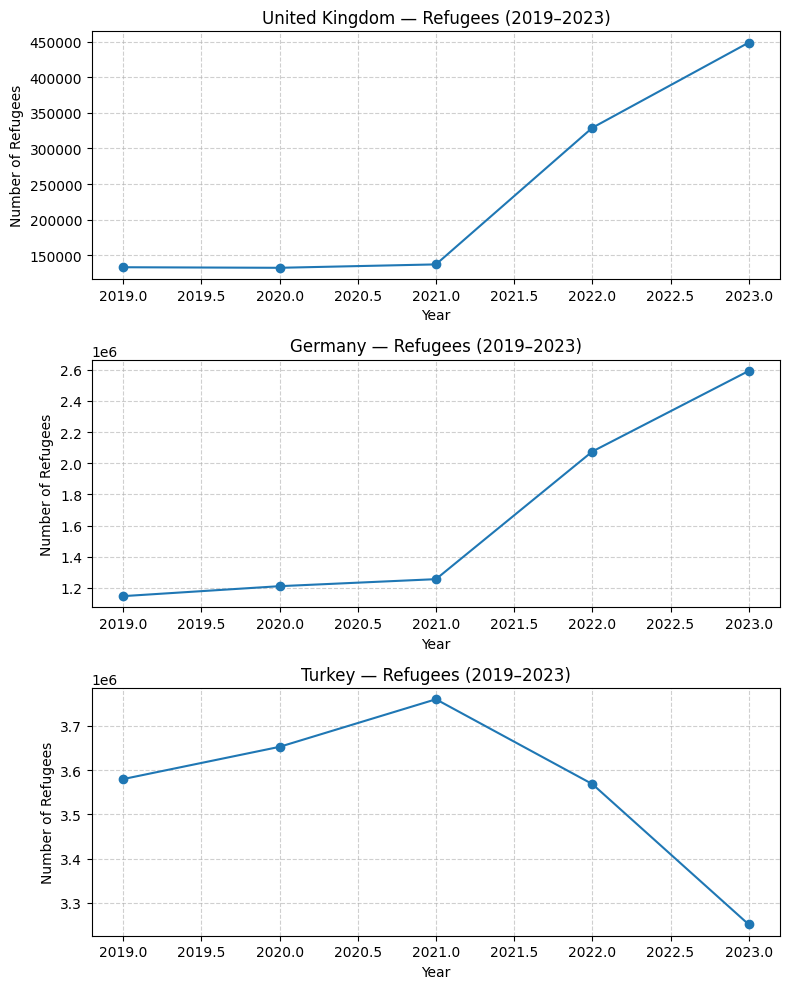

In [5]:
# ============================================================
# Cell 4 — Exploratory Trend Plots (2019–2023)
# ------------------------------------------------------------
# Produces simple line charts for Germany, the United Kingdom,
# and Turkey (labelled as “Turkiye” in the dataset) to visually
# inspect refugee inflow completeness and identify potential
# anomalies across 2019–2023.
# ============================================================

import matplotlib.pyplot as plt

# --- Map display names to corresponding dataset labels ---
country_map = {
    'United Kingdom': 'United Kingdom of Great Britain and Northern Ireland',
    'Germany': 'Germany',
    'Turkey': 'Turkiye',  # Display name 'Turkey' corresponds to dataset label 'Turkiye'
}

# --- Create subplots (one per country) ---
fig, axes = plt.subplots(len(country_map), 1, figsize=(8, 10))
if len(country_map) == 1:
    axes = [axes]

# --- Plot refugee trends by year ---
for ax, (short_name, full_name) in zip(axes, country_map.items()):
    sub = df_filtered[df_filtered['Country of Asylum'] == full_name].sort_values('Year')
    ax.plot(sub['Year'], sub['Refugees'], marker='o')
    ax.set_title(f'{short_name} — Refugees (2019–2023)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Refugees')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Cell 5 — Prepare Country-Specific Subsets

In [6]:
# ============================================================
# Cell 5 — Prepare Country-Specific Subsets
# ------------------------------------------------------------
# Normalises country names for modelling and plotting, ensuring
# consistency across data sources. Creates separate DataFrames
# for the United Kingdom, Germany, and Turkey for independent
# time-series analysis and forecasting.
# ============================================================

# --- Normalise country names ---
normalise_map = {
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Turkiye': 'Turkey',
    'Türkiye': 'Turkey',  # safeguard alternative spelling
}
df_filtered['Country of Asylum'] = df_filtered['Country of Asylum'].replace(normalise_map)

# --- Standard labels for reuse ---
UK_LABEL = 'United Kingdom'
DE_LABEL = 'Germany'
TR_LABEL = 'Turkey'

# --- Create country-specific subsets ---
uk_data = df_filtered[df_filtered['Country of Asylum'] == UK_LABEL].copy()
de_data = df_filtered[df_filtered['Country of Asylum'] == DE_LABEL].copy()
tr_data = df_filtered[df_filtered['Country of Asylum'] == TR_LABEL].copy()

# --- Sanity checks ---
for name, sub in [(UK_LABEL, uk_data), (DE_LABEL, de_data), (TR_LABEL, tr_data)]:
    years = sorted(sub['Year'].unique().tolist())
    print(f"{name}: years present -> {years} (n={len(years)})")
    if len(years) < 3:
        print(f"  Warning: limited number of years for {name}; "
              f"train/test split may be unreliable.")


United Kingdom: years present -> [2019, 2020, 2021, 2022, 2023] (n=5)
Germany: years present -> [2019, 2020, 2021, 2022, 2023] (n=5)
Turkey: years present -> [2019, 2020, 2021, 2022, 2023] (n=5)


# Cell 6 — Helper Function: Training and Evaluation (Linear Regression by Default)

In [7]:
# ============================================================
# Cell 6 — Helper Function: Training and Evaluation (Linear Regression by Default)
# ------------------------------------------------------------
# Defines a reusable function to train and evaluate regression models
# for each country subset. The default model is a simple Linear Regression.
# Evaluation uses a year-based split (train: < test_year, test: == test_year).
# ============================================================

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

def train_and_evaluate(country_df, country_label, model=None, test_year_preferred=2023):
    """
    Trains and evaluates a model on the provided country's dataset using
    a year-based split (train: < test_year, test: == test_year).

    Returns:
        model: The fitted estimator.
        metrics: A dictionary containing MAE (primary), R² (if applicable),
                 and predicted versus actual values.
    """
    sub = country_df[['Year', 'Refugees']].dropna().sort_values('Year').copy()
    if sub.empty:
        return None, {
            'country': country_label,
            'note': 'No data available after cleaning.',
            'test_year': None, 'r2': None, 'mae': None,
            'y_true': [], 'y_pred': []
        }

    X = sub['Year'].to_numpy().reshape(-1, 1)
    y = sub['Refugees'].to_numpy()

    years = np.sort(sub['Year'].unique())
    test_year = int(test_year_preferred) if test_year_preferred in years else int(years[-1])

    X_train, y_train = X[sub['Year'] < test_year], y[sub['Year'] < test_year]
    X_test,  y_test  = X[sub['Year'] == test_year], y[sub['Year'] == test_year]

    if X_train.size == 0 or X_test.size == 0:
        return None, {
            'country': country_label,
            'note': 'Insufficient data for a valid train/test split.',
            'test_year': test_year, 'r2': None, 'mae': None,
            'y_true': y_test.tolist() if y_test.size else [], 'y_pred': []
        }

    # Avoid implicit truth checks; explicit None handling ensures clarity.
    estimator = model if model is not None else LinearRegression()
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)

    single_test = y_test.size == 1
    r2 = r2_score(y_test, y_pred) if not single_test else None
    mae = mean_absolute_error(y_test, y_pred)

    return estimator, {
        'country': country_label,
        'note': 'Single test year; R² is undefined.' if single_test else None,
        'test_year': test_year,
        'r2': float(r2) if r2 is not None else None,
        'mae': float(mae),
        'y_true': y_test.tolist(),
        'y_pred': y_pred.tolist()
    }

# ============================================================
# Smoke Test — Quick Validation of Functionality
# ------------------------------------------------------------
# Runs a lightweight test with Linear Regression on all
# three country datasets to ensure the function operates correctly.
# ============================================================

import pandas as pd
from sklearn.linear_model import LinearRegression

try:
    test_pairs = [("United Kingdom", uk_data), ("Germany", de_data), ("Turkey", tr_data)]
    results = []
    for label, df_c in test_pairs:
        model, metrics = train_and_evaluate(df_c, label, LinearRegression())
        results.append({
            "Country": label,
            "Model": "LinearRegression",
            "Test Year": metrics['test_year'],
            "MAE": metrics['mae'],
            "R²": metrics['r2'],
            "Note": metrics['note']
        })
    smoke_tbl = pd.DataFrame(results)
    print("[Cell 6] Smoke test completed using Linear Regression:")
    display(smoke_tbl)
except Exception as e:
    print(f"[Cell 6] train_and_evaluate() defined, but smoke test failed: {e}")


[Cell 6] Smoke test completed using Linear Regression:


,Country,Model,Test Year,MAE,R²,Note
0,United Kingdom,LinearRegression,2023,117633.5,None,Single test year; R² is undefined.
1,Germany,LinearRegression,2023,463056.0,None,Single test year; R² is undefined.
2,Turkey,LinearRegression,2023,407275.0,None,Single test year; R² is undefined.


# Cell 7 — Linear Regression Results and Visual Comparison

,country,note,test_year,r2,mae,y_true,y_pred
0,United Kingdom,Single test year; R² is undefined.,2023,None,117633.5,[448620],[330986.5]
1,Germany,Single test year; R² is undefined.,2023,None,463056.0,[2593007],[2129951.0]
2,Turkey,Single test year; R² is undefined.,2023,None,407275.0,[3251127],[3658402.0]


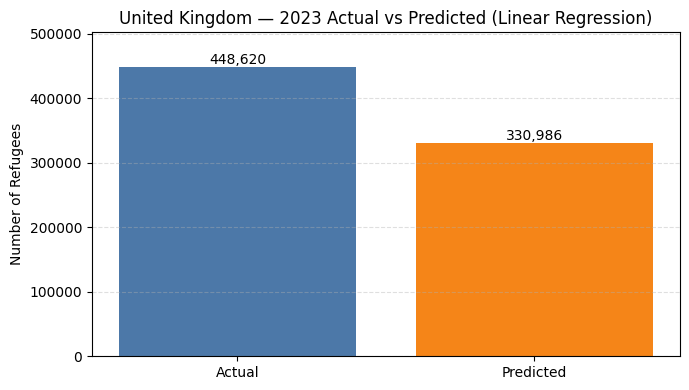

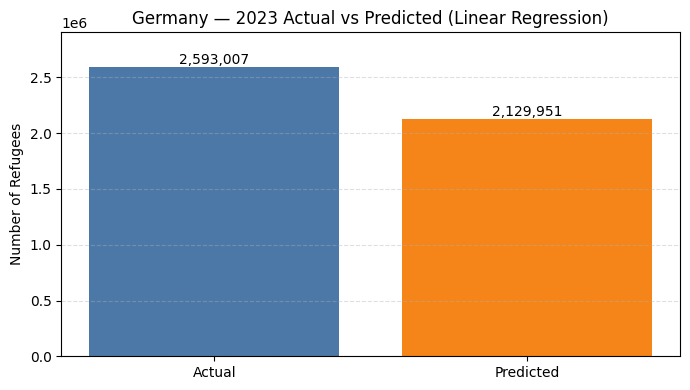

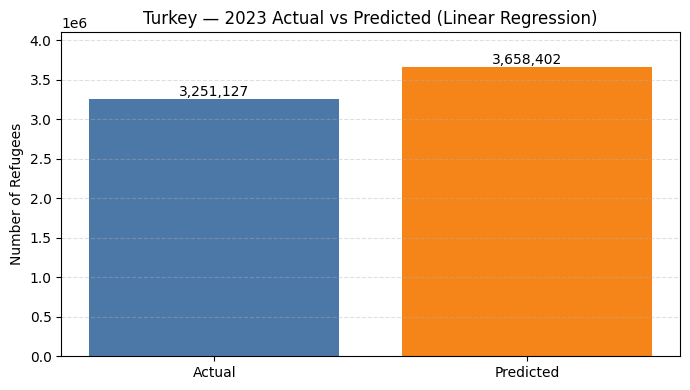

In [8]:
# ============================================================
# Cell 7 — Linear Regression Results and Visual Comparison
# ------------------------------------------------------------
# Fits Linear Regression models for Germany, the United Kingdom,
# and Turkey using the helper function. Displays evaluation metrics
# (MAE, R²) and produces simple bar charts comparing actual and
# predicted refugee counts for the latest test year.
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.linear_model import LinearRegression

# --- Train and evaluate models (Linear Regression) ---
lr_uk, res_lr_uk = train_and_evaluate(uk_data, "United Kingdom", LinearRegression())
lr_de, res_lr_de = train_and_evaluate(de_data, "Germany", LinearRegression())
lr_tr, res_lr_tr = train_and_evaluate(tr_data, "Turkey", LinearRegression())

# --- Display results table ---
results_lr = pd.DataFrame([res_lr_uk, res_lr_de, res_lr_tr])
display(results_lr)

# Add spacing after table for readability
display(HTML("<div style='height:24px'></div>"))

# ============================================================
# Helper Function — Actual vs Predicted Bar Plot
# ------------------------------------------------------------
# Generates a simple two-bar comparison (Actual vs Predicted)
# for the specified country and test year.
# ============================================================

def plot_actual_vs_pred_bar(country_df, country_label, model, test_year,
                            bar_colors=("#4C78A8", "#F58518"),
                            figsize=(7, 4), ylim_pad=0.12):
    if model is None or test_year is None:
        print(f"{country_label}: no model or test year to plot.")
        return

    sub = country_df[country_df['Year'] == test_year]
    if sub.empty:
        print(f"{country_label}: no data for {test_year}.")
        return

    X_test = sub[['Year']].to_numpy()
    y_test = sub['Refugees'].to_numpy()
    y_pred = model.predict(X_test)

    categories = ["Actual", "Predicted"]
    values = [float(y_test[0]), float(y_pred[0])]

    plt.figure(figsize=figsize)
    bars = plt.bar(categories, values, color=bar_colors)
    plt.title(f"{country_label} — {int(test_year)} Actual vs Predicted (Linear Regression)")
    plt.ylabel("Number of Refugees")

    ymax = max(values) if values else 0
    plt.ylim(0, (1 + ylim_pad) * ymax if ymax > 0 else 1)

    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width() / 2.0, h, f"{int(round(h)):,}",
                 ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# ============================================================
# Generate bar plots for all three countries
# ============================================================

plot_actual_vs_pred_bar(uk_data, "United Kingdom", lr_uk, res_lr_uk.get('test_year'))
display(HTML("<div style='height:16px'></div>"))

plot_actual_vs_pred_bar(de_data, "Germany", lr_de, res_lr_de.get('test_year'))
display(HTML("<div style='height:16px'></div>"))

plot_actual_vs_pred_bar(tr_data, "Turkey", lr_tr, res_lr_tr.get('test_year'))
display(HTML("<div style='height:8px'></div>"))


# Cell 8 — Model Comparison: Linear Regression, Decision Tree, and Random Forest

In [9]:
# ============================================================
# Cell 8 — Model Comparison: Linear Regression, Decision Tree, and Random Forest
# ------------------------------------------------------------
# Compares three baseline regression algorithms for each country:
# Linear Regression, Decision Tree, and Random Forest.
# Uses the helper function from Cell 6 for training and evaluation.
# ============================================================

from sklearn.base import clone
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import pandas as pd

# --- Model registry (baseline estimators) ---
MODEL_REGISTRY = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42, n_estimators=200),
}

# ============================================================
# Function — Run all models for a given country
# ------------------------------------------------------------
# Trains and evaluates each model defined in MODEL_REGISTRY
# for a specified country dataset. Returns both results and
# fitted estimators for later inspection.
# ============================================================

def run_all_models(country_df, country_label):
    rows, fitted = [], {}
    for name, base_model in MODEL_REGISTRY.items():
        mdl = clone(base_model)  # fresh, unfitted estimator
        model, res = train_and_evaluate(country_df, country_label, mdl)
        rows.append({
            'country': country_label,
            'model': name,
            'model_class': model.__class__.__name__ if model is not None else None,
            'test_year': res.get('test_year'),
            'mae': res.get('mae'),
            'r2': res.get('r2'),
            'note': res.get('note')
        })
        fitted[name] = (model, res)
    return pd.DataFrame(rows), fitted

# ============================================================
# Run comparison for all three countries
# ============================================================

tbl_uk, fit_uk = run_all_models(uk_data, "United Kingdom")
tbl_de, fit_de = run_all_models(de_data, "Germany")
tbl_tr, fit_tr = run_all_models(tr_data, "Turkey")

# --- Combine results for inspection ---
compare_tbl = pd.concat([tbl_uk, tbl_de, tbl_tr], ignore_index=True)
display(compare_tbl.sort_values(['country', 'model']))


,country,model,model_class,test_year,mae,r2,note
4,Germany,DecisionTree,DecisionTreeRegressor,2023,517562.000,None,Single test year; R² is undefined.
3,Germany,LinearRegression,LinearRegression,2023,463056.000,None,Single test year; R² is undefined.
5,Germany,RandomForest,RandomForestRegressor,2023,820378.955,None,Single test year; R² is undefined.
7,Turkey,DecisionTree,DecisionTreeRegressor,2023,317132.000,None,Single test year; R² is undefined.
6,Turkey,LinearRegression,LinearRegression,2023,407275.000,None,Single test year; R² is undefined.
8,Turkey,RandomForest,RandomForestRegressor,2023,378454.270,None,Single test year; R² is undefined.
1,United Kingdom,DecisionTree,DecisionTreeRegressor,2023,119631.000,None,Single test year; R² is undefined.
0,United Kingdom,LinearRegression,LinearRegression,2023,117633.500,None,Single test year; R² is undefined.
2,United Kingdom,RandomForest,RandomForestRegressor,2023,190060.435,None,Single test year; R² is undefined.


# Cell 9 — Visualising Linear Regression Fit and Test-Year Comparison

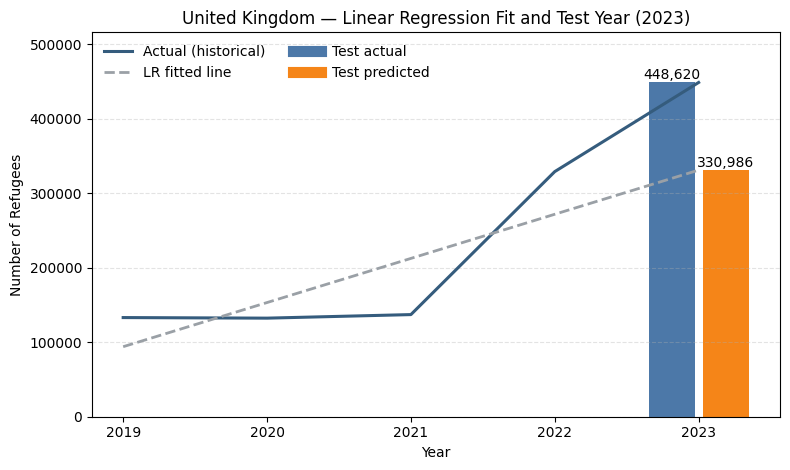

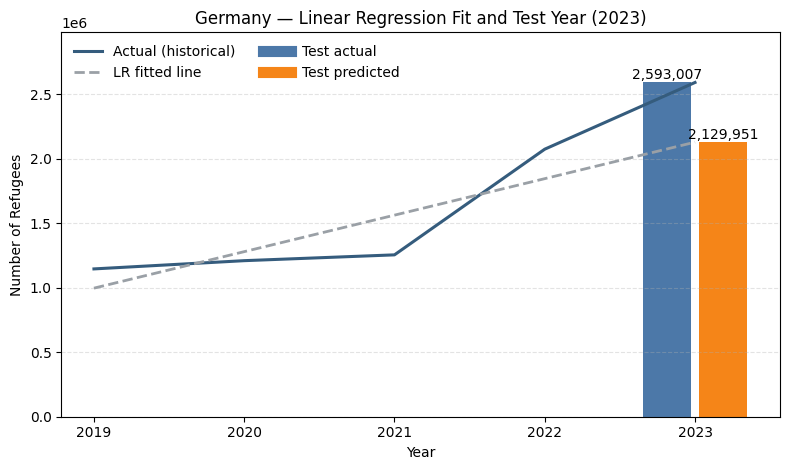

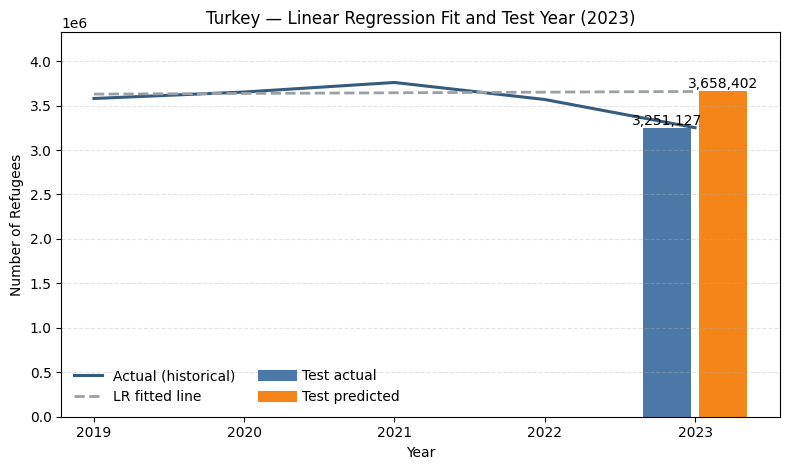

In [10]:
# ============================================================
# Cell 9 — Visualising Linear Regression Fit and Test-Year Comparison
# ------------------------------------------------------------
# Plots fitted Linear Regression trend lines alongside the
# actual data for each country, including bar markers for the
# test-year actual and predicted refugee counts.
# This visualisation helps assess how well the fitted model
# generalises to the most recent year.
# ============================================================

from IPython.display import HTML, display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# ============================================================
# Function — Plot fitted trend with test-year comparison
# ============================================================

def plot_lr_fit_with_test_clean(country_df, country_label, model, test_year,
                                figsize=(8, 4.8),
                                line_colours=("#355C7D", "#9AA0A6"),
                                bar_colours=("#4C78A8", "#F58518"),
                                bar_width=0.32, y_pad=0.15):
    """
    Plots the fitted Linear Regression line together with the
    actual data points and highlights the test-year prediction.
    """
    if model is None or test_year is None:
        print(f"{country_label}: no Linear Regression model or test year available.")
        return

    sub = country_df[['Year', 'Refugees']].dropna().sort_values('Year').copy()
    if sub.empty:
        print(f"{country_label}: no data available to visualise.")
        return

    years = sub['Year'].to_numpy()
    y_actual = sub['Refugees'].to_numpy().astype(float)
    X_all = years.reshape(-1, 1)
    y_fit = model.predict(X_all).astype(float)

    sub_test = sub[sub['Year'] == test_year]
    if sub_test.empty:
        print(f"{country_label}: no data for {test_year}.")
        return

    X_test = sub_test[['Year']].to_numpy()
    y_test = sub_test['Refugees'].to_numpy().astype(float)
    y_pred = model.predict(X_test).astype(float)

    # --- Plot configuration ---
    plt.figure(figsize=figsize)
    plt.plot(years, y_actual, label="Actual (historical)", linewidth=2.2, color=line_colours[0])
    plt.plot(years, y_fit, label="LR fitted line", linewidth=2.0, linestyle="--", color=line_colours[1])

    x_left = float(test_year) - bar_width / 1.7
    x_right = float(test_year) + bar_width / 1.7
    bars = plt.bar([x_left, x_right], [y_test[0], y_pred[0]],
                   width=bar_width, color=[bar_colours[0], bar_colours[1]])

    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width() / 2.0, h, f"{int(round(h)):,}",
                 ha="center", va="bottom")

    plt.title(f"{country_label} — Linear Regression Fit and Test Year ({int(test_year)})")
    plt.xlabel("Year")
    plt.ylabel("Number of Refugees")
    plt.grid(axis="y", linestyle="--", alpha=0.35)

    y_max = max(np.max(y_actual), np.max(y_fit), y_test[0], y_pred[0])
    plt.ylim(0, (1 + y_pad) * y_max if y_max > 0 else 1)
    plt.xticks(years)

    legend_items = [
        Line2D([0], [0], color=line_colours[0], lw=2.2, label="Actual (historical)"),
        Line2D([0], [0], color=line_colours[1], lw=2.0, ls="--", label="LR fitted line"),
        Line2D([0], [0], color=bar_colours[0], lw=8, label="Test actual"),
        Line2D([0], [0], color=bar_colours[1], lw=8, label="Test predicted"),
    ]
    plt.legend(handles=legend_items, frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()

# ============================================================
# Render plots for all three countries
# ============================================================

plot_lr_fit_with_test_clean(uk_data, "United Kingdom", lr_uk, res_lr_uk.get('test_year'))
display(HTML("<div style='height:16px'></div>"))

plot_lr_fit_with_test_clean(de_data, "Germany", lr_de, res_lr_de.get('test_year'))
display(HTML("<div style='height:16px'></div>"))

plot_lr_fit_with_test_clean(tr_data, "Turkey", lr_tr, res_lr_tr.get('test_year'))
display(HTML("<div style='height:8px'></div>"))


# Cell 10 — Comparative Model Fit (Linear Regression, Decision Tree, Random Forest)

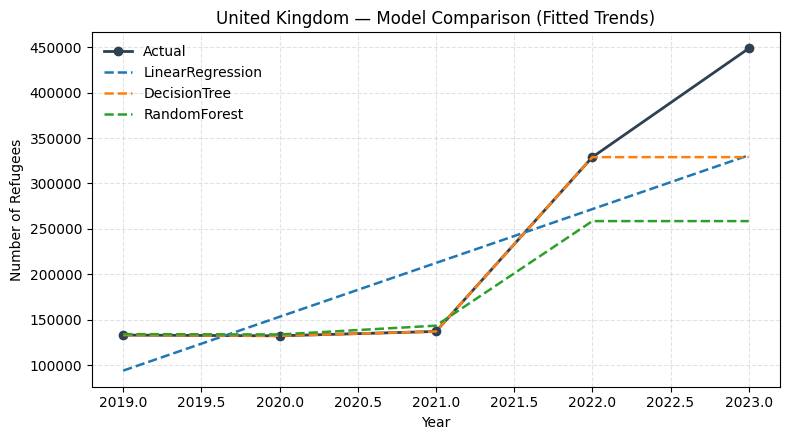

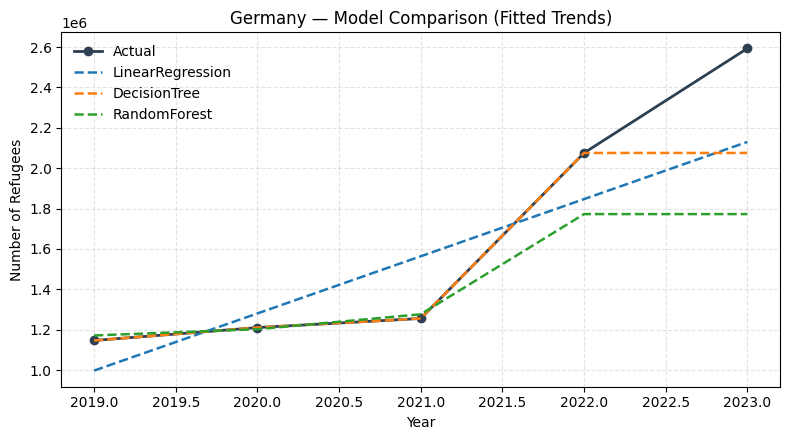

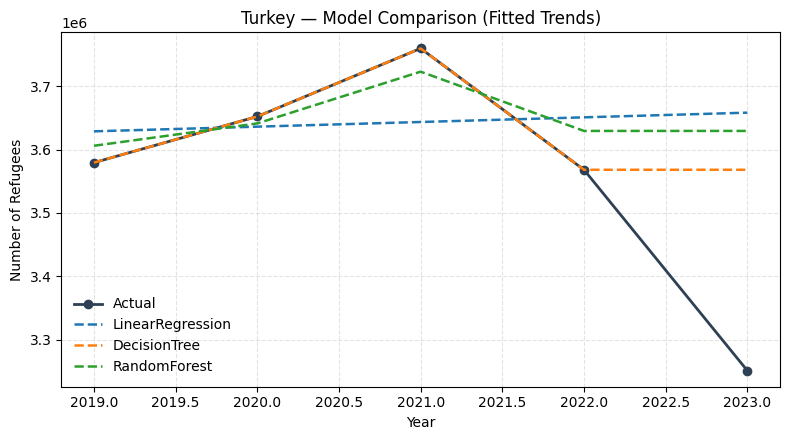

In [11]:
# ============================================================
# Cell 10 — Comparative Model Fit (Linear Regression, Decision Tree, Random Forest)
# ------------------------------------------------------------
# Compares fitted lines from the three baseline models for each
# country on a single plot. This visualisation highlights the
# differences in smoothness and extrapolation behaviour.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

def plot_model_comparison(country_df, country_label, fitted_models, figsize=(8, 4.5)):
    """
    Plots fitted trends for Linear Regression, Decision Tree,
    and Random Forest on the same axis for visual comparison.
    """
    sub = country_df[['Year', 'Refugees']].dropna().sort_values('Year').copy()
    if sub.empty:
        print(f"{country_label}: no data available to plot.")
        return

    years = sub['Year'].to_numpy()
    y_actual = sub['Refugees'].to_numpy().astype(float)
    X_all = years.reshape(-1, 1)

    plt.figure(figsize=figsize)
    plt.plot(years, y_actual, 'o-', color='#2E4053', linewidth=2.0, label='Actual')

    for name, (model, res) in fitted_models.items():
        if model is None:
            continue
        y_pred = model.predict(X_all).astype(float)
        plt.plot(years, y_pred, linestyle='--', linewidth=1.8, label=name)

    plt.title(f"{country_label} — Model Comparison (Fitted Trends)")
    plt.xlabel("Year")
    plt.ylabel("Number of Refugees")
    plt.grid(alpha=0.35, linestyle='--')
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

# ============================================================
# Render comparison plots for all three countries
# ============================================================

plot_model_comparison(uk_data, "United Kingdom", fit_uk)
display(HTML("<div style='height:16px'></div>"))

plot_model_comparison(de_data, "Germany", fit_de)
display(HTML("<div style='height:16px'></div>"))

plot_model_comparison(tr_data, "Turkey", fit_tr)
display(HTML("<div style='height:8px'></div>"))


# Cell 11 — Leave-One-Year-Out Cross-Validation (LOYO-CV) Summary

In [12]:
# ============================================================
# Cell 11 — Leave-One-Year-Out Cross-Validation (LOYO-CV) Summary
# ------------------------------------------------------------
# Purpose:
#   Provides a robust evaluation for small yearly datasets
#   (typically 2019–2023). For each available year, trains the
#   model on all other years and tests on the held-out year.
#
# Outputs:
#   • Mean MAE across folds
#   • Cross-validated R² computed over all held-out predictions
#   • Summary table for three baseline models and three countries
#
# Safety / robustness:
#   • Aggregates to ONE (Year -> Refugees) value inside the function
#     (protects against accidental duplicates if upstream changes)
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ============================================================
# Function — LOYO-CV (safe) for a single model and country
# ============================================================

def loyo_cv(country_df, base_model, min_train_points=2, agg="sum"):
    """
    Runs Leave-One-Year-Out cross-validation for a single model
    and country subset.

    Args:
        country_df (DataFrame): Country-specific data with columns (Year, Refugees).
        base_model: scikit-learn estimator to clone and train.
        min_train_points (int): Minimum number of training points required.
        agg (str): Aggregation for duplicates per Year: 'sum' or 'mean'.

    Returns:
        dict: Per-fold predictions and aggregate metrics.
              - folds: list of dicts with year, y_true, y_pred, abs_err
              - mean_mae: mean absolute error across folds
              - cv_r2: R² across concatenated held-out predictions (None if <2 folds)
    """
    sub = country_df[["Year", "Refugees"]].dropna().copy()
    sub["Year"] = pd.to_numeric(sub["Year"], errors="coerce")
    sub["Refugees"] = pd.to_numeric(sub["Refugees"], errors="coerce")
    sub = sub.dropna().sort_values("Year")

    # Ensure exactly one row per year (protects against duplicates)
    if agg not in {"sum", "mean"}:
        raise ValueError("agg must be either 'sum' or 'mean'.")
    if agg == "sum":
        sub = sub.groupby("Year", as_index=False)["Refugees"].sum()
    else:
        sub = sub.groupby("Year", as_index=False)["Refugees"].mean()

    years = sub["Year"].unique()
    folds = []

    for y in years:
        train = sub[sub["Year"] != y]
        test = sub[sub["Year"] == y]

        if len(train) < min_train_points:
            continue

        X_tr = train[["Year"]].to_numpy()
        y_tr = train["Refugees"].to_numpy()
        X_te = test[["Year"]].to_numpy()
        y_te = test["Refugees"].to_numpy()

        model = clone(base_model)
        model.fit(X_tr, y_tr)
        yhat = model.predict(X_te)

        folds.append({
            "year": int(y),
            "y_true": float(y_te[0]),
            "y_pred": float(yhat[0]),
            "abs_err": float(abs(yhat[0] - y_te[0]))
        })

    if not folds:
        return {"folds": [], "mean_mae": None, "cv_r2": None}

    y_true_all = np.array([f["y_true"] for f in folds], dtype=float)
    y_pred_all = np.array([f["y_pred"] for f in folds], dtype=float)

    mean_mae = float(np.mean(np.abs(y_true_all - y_pred_all)))
    cv_r2 = float(r2_score(y_true_all, y_pred_all)) if len(folds) > 1 else None

    return {"folds": folds, "mean_mae": mean_mae, "cv_r2": cv_r2}

# ============================================================
# Function — Produce LOYO-CV summary for all models per country
# ============================================================

CV_MODELS = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_estimators=200)
}

def cv_table_for_country(country_df, country_label):
    rows = []
    for name, model in CV_MODELS.items():
        res = loyo_cv(country_df, model, agg="sum")
        rows.append({
            "country": country_label,
            "model": name,
            "mean_MAE_LOYO": res["mean_mae"],
            "CV_R²": res["cv_r2"]
        })
    return pd.DataFrame(rows)

# ============================================================
# Run LOYO-CV for all three countries and display results
# ============================================================

cv_tbl = pd.concat([
    cv_table_for_country(uk_data, "United Kingdom"),
    cv_table_for_country(de_data, "Germany"),
    cv_table_for_country(tr_data, "Turkey")
], ignore_index=True)

display(
    cv_tbl
    .sort_values(["country", "model"])
    .round({
        "mean_MAE_LOYO": 1,
        "CV_R²": 3
    })
)


,country,model,mean_MAE_LOYO,CV_R²
4,Germany,DecisionTree,302047.8,0.432
3,Germany,LinearRegression,346092.9,0.495
5,Germany,RandomForest,338312.6,0.405
7,Turkey,DecisionTree,152361.4,-0.105
6,Turkey,LinearRegression,223770.4,-1.409
8,Turkey,RandomForest,140953.7,-0.212
1,United Kingdom,DecisionTree,63574.8,0.398
0,United Kingdom,LinearRegression,88466.1,0.356
2,United Kingdom,RandomForest,78222.8,0.369


# Cell 12 — Build Per-Fold LOYO-CV Tables for Thesis

In [13]:
# ============================================================
# Cell 12 — Build Per-Fold LOYO-CV Tables for Thesis
# ------------------------------------------------------------
# Creates detailed per-fold tables for each model and country
# using the previously defined LOYO-CV function (Cell 11).
# Each row records the test year, corresponding training years,
# residuals, and error direction, providing transparent
# year-level validation data for inclusion in the dissertation.
# ============================================================

import numpy as np
import pandas as pd

def loyo_perfold_table(country_df, country_label, model_name, model_obj):
    """
    Expands the LOYO-CV results into a per-fold DataFrame
    containing actual and predicted values, residuals, and
    the training–testing year structure.
    """
    res = loyo_cv(country_df, model_obj)  # uses Cell 11 loyo_cv()
    years_all = sorted(country_df['Year'].dropna().unique())
    rows = []

    for f in res['folds']:
        test_y = int(f['year'])
        y_true = float(f['y_true'])
        y_pred = float(f['y_pred'])
        mae = float(abs(y_pred - y_true))
        resid = float(y_pred - y_true)
        sign = "over" if resid > 0 else ("under" if resid < 0 else "exact")

        train_years = [int(y) for y in years_all if int(y) != test_y]
        train_range = (
            f"{train_years[0]}–{train_years[-1]}".replace("--", "–")
            if len(train_years) > 1 else ",".join(map(str, train_years))
        )

        rows.append({
            "Country": country_label,
            "Model": model_name,
            "Test Year": test_y,
            "Train Years": train_range,
            "Actual": y_true,
            "Predicted": y_pred,
            "Residual (Pred−Actual)": resid,
            "Residual Sign": sign,
            "MAE": mae
        })

    return pd.DataFrame(rows).sort_values("Test Year")


# Cell 13 — Compact Hyperparameter Tuning under LOYO-CV (Decision Tree & Random Forest)

In [14]:
# ============================================================
# Cell 13 — Compact Hyperparameter Tuning under LOYO-CV (Decision Tree & Random Forest)
# ------------------------------------------------------------
# Purpose:
#   Demonstrates principled model selection using Leave-One-Year-Out
#   cross-validation on small datasets (2019–2023).
#
# Strategy:
#   • Very small parameter grids to maintain interpretability
#     and avoid overfitting on limited data.
#   • Selects configuration with the lowest mean MAE across folds.
#
# Outputs:
#   • Best parameters per country for Decision Tree and Random Forest
#   • Corresponding LOYO-CV metrics (mean MAE, cross-validated R²)
# ============================================================

from itertools import product

# ============================================================
# Function — Tiny Grid Search with LOYO-CV
# ============================================================

def tiny_grid_search_loyo(country_df, build_model_fn, param_grid):
    """
    Performs an exhaustive search over a very small grid using LOYO-CV.
    Returns the configuration with the lowest mean MAE.

    Args:
        country_df (DataFrame): Country-specific data subset.
        build_model_fn (callable): Function returning an unfitted estimator
                                   given a set of parameters.
        param_grid (dict): Dictionary of hyperparameters to evaluate.

    Returns:
        dict: Best configuration and associated LOYO-CV metrics.
    """
    best = None
    for combo in product(*param_grid.values()):
        params = dict(zip(param_grid.keys(), combo))
        model = build_model_fn(params)
        res = loyo_cv(country_df, model)
        score = res['mean_mae']  # lower is better
        row = {'params': params, 'mean_MAE_LOYO': score, 'CV_R²': res['cv_r2']}
        if best is None or (score is not None and score < best['mean_MAE_LOYO']):
            best = row
    return best

# ============================================================
# Define Minimal Hyperparameter Grids
# ============================================================

DT_GRID = {'max_depth': [2, 3, 4], 'min_samples_leaf': [1, 2]}
RF_GRID = {'n_estimators': [100, 200], 'max_depth': [None, 4], 'min_samples_leaf': [1, 2]}

def build_dt(params, seed=42):
    return DecisionTreeRegressor(random_state=seed, **params)

def build_rf(params, seed=42):
    return RandomForestRegressor(random_state=seed, **params)

# ============================================================
# Execute Tuning for Each Country
# ============================================================

rows = []
for label, df_c in [("United Kingdom", uk_data), ("Germany", de_data), ("Turkey", tr_data)]:
    best_dt = tiny_grid_search_loyo(df_c, build_dt, DT_GRID)
    best_rf = tiny_grid_search_loyo(df_c, build_rf, RF_GRID)
    rows.append({'country': label, 'model': 'DecisionTree', **(best_dt or {})})
    rows.append({'country': label, 'model': 'RandomForest', **(best_rf or {})})

# ============================================================
# Display Results
# ============================================================

best_params_tbl = pd.DataFrame(rows)
display(best_params_tbl.sort_values(['country', 'model'])
        .round({'mean_MAE_LOYO': 1, 'CV_R²': 3}))


,country,model,params,mean_MAE_LOYO,CV_R²
2,Germany,DecisionTree,"{'max_depth': 2, 'min_samples_leaf': 2}",250291.6,0.464
3,Germany,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_...",335846.6,0.464
4,Turkey,DecisionTree,"{'max_depth': 3, 'min_samples_leaf': 1}",152361.4,-0.105
5,Turkey,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_...",137280.7,-0.147
0,United Kingdom,DecisionTree,"{'max_depth': 2, 'min_samples_leaf': 2}",52099.1,0.437
1,United Kingdom,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_...",77431.1,0.431


# Cell 14 — Reproducibility: Global Random State and Library Versions

In [15]:
# ============================================================
# Cell 14 — Reproducibility: Global Random State and Library Versions
# ------------------------------------------------------------
# Purpose:
#   Ensures full academic reproducibility by setting fixed random
#   seeds across Python, NumPy, and scikit-learn.
#   Records key library versions for transparent documentation.
#
# Patch Note:
#   Model constructors that include stochastic elements (e.g.
#   DecisionTreeRegressor, RandomForestRegressor) are bound to
#   the same global SEED for consistent re-runs.
# ============================================================

import sys, random, numpy as np, pandas as pd, sklearn, matplotlib

# --- Global seed for all random operations ---
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# --- Print core environment versions ---
print("Python version:", sys.version.split()[0])
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("scikit-learn version:", sklearn.__version__)
print("Matplotlib version:", matplotlib.__version__)

# ============================================================
# Patch Note — Rebind Models with Fixed SEED
# ------------------------------------------------------------
# If models were previously defined (e.g., in Cell 8), this step
# ensures all randomised estimators use the global SEED.
# Re-run Cell 8 afterwards if you wish to refresh results.
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

MODEL_REGISTRY = {
    'LinearRegression': LinearRegression(),
    'DecisionTree': DecisionTreeRegressor(random_state=SEED),
    'RandomForest': RandomForestRegressor(random_state=SEED, n_estimators=200)
}


Python version: 3.12.12
NumPy version: 2.0.2
Pandas version: 2.2.2
scikit-learn version: 1.6.1
Matplotlib version: 3.10.0


# Cell 15 — Data Validation and Export of Key Tables

In [16]:
# ============================================================
# Cell 15 — Data Validation and Export of Key Tables
# ------------------------------------------------------------
# Purpose:
#   Constructs a unified dataset from the three country-specific
#   dataframes (United Kingdom, Germany, Turkey), validates schema
#   integrity, checks for missing years and outliers, and exports
#   the main LOYO-CV results for archival and reproducibility.
# ============================================================

import pandas as pd
import numpy as np
import os

# ============================================================
# 1) Combine country-specific subsets into a unified dataset
# ============================================================

df_all = pd.concat([
    uk_data.assign(**{"Country of Asylum": "United Kingdom"})[["Year", "Refugees", "Country of Asylum"]],
    de_data.assign(**{"Country of Asylum": "Germany"})[["Year", "Refugees", "Country of Asylum"]],
    tr_data.assign(**{"Country of Asylum": "Turkey"})[["Year", "Refugees", "Country of Asylum"]],
], ignore_index=True)

# ============================================================
# 2) Canonicalise types and perform basic cleaning
# ============================================================

df_all["Year"] = pd.to_numeric(df_all["Year"], errors="coerce").astype("Int64")
df_all["Refugees"] = pd.to_numeric(df_all["Refugees"], errors="coerce")

df_filtered = (
    df_all.dropna(subset=["Year", "Refugees", "Country of Asylum"])
          .astype({"Year": "int64"})
          .sort_values(["Country of Asylum", "Year"])
          .reset_index(drop=True)
)

# ============================================================
# 3) Schema and logical checks
# ============================================================

required_cols = ["Year", "Country of Asylum", "Refugees"]
assert all(c in df_filtered.columns for c in required_cols), \
       f"Missing required columns. Found: {list(df_filtered.columns)}"

assert pd.api.types.is_integer_dtype(df_filtered["Year"]), "Year should be integer-like."
assert (df_filtered["Refugees"] >= 0).all(), "Refugee counts must be non-negative."

# ============================================================
# 4) Duplicates after cleaning
# ============================================================

dups = df_filtered.duplicated(["Country of Asylum", "Year"]).sum()
print("Duplicate (Country, Year) rows after cleaning:", int(dups))

# ============================================================
# 5) Identify missing years per country
# ============================================================

def missing_years(series):
    all_years = set(range(int(series.min()), int(series.max()) + 1))
    return sorted(all_years - set(map(int, series)))

missing_by_country = (
    df_filtered.groupby("Country of Asylum")["Year"]
    .apply(missing_years)
    .reset_index(name="Missing Years")
)
display(missing_by_country)

# ============================================================
# 6) Simple outlier flag (IQR method)
# ============================================================

def iqr_flags(group, k=1.5):
    q1, q3 = group["Refugees"].quantile(0.25), group["Refugees"].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - k * iqr, q3 + k * iqr
    group = group.copy()
    group["Outlier Flag"] = (group["Refugees"] < lo) | (group["Refugees"] > hi)
    return group

df_valid = df_filtered.groupby("Country of Asylum", group_keys=False).apply(iqr_flags)
display(df_valid[df_valid["Outlier Flag"]].head(10))

# ============================================================
# 7) Export validated tables and CV results
# ============================================================

os.makedirs("/content/tables", exist_ok=True)

# Export LOYO-CV summary table (from Cell 11)
try:
    cv_tbl.to_csv("/content/tables/results_cv_loyo_mean.csv", index=False)
    print("Saved:", "/content/tables/results_cv_loyo_mean.csv")
except Exception as e:
    print("cv_tbl not found or failed to save:", e)

# Inform about per-fold exports (from earlier cells)
print("Per-fold CSVs (from earlier cells) should be available in /content/tables/")
print("   e.g.: united_kingdom_loyo_perfold.csv, germany_loyo_perfold.csv, turkey_loyo_perfold.csv")


Duplicate (Country, Year) rows after cleaning: 0


,Country of Asylum,Missing Years
0,Germany,[]
1,Turkey,[]
2,United Kingdom,[]


/tmp/ipython-input-2306066216.py:84: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_valid = df_filtered.groupby("Country of Asylum", group_keys=False).apply(iqr_flags)


,Year,Refugees,Country of Asylum,Outlier Flag
9,2023,3251127,Turkey,True


Saved: /content/tables/results_cv_loyo_mean.csv
Per-fold CSVs (from earlier cells) should be available in /content/tables/
   e.g.: united_kingdom_loyo_perfold.csv, germany_loyo_perfold.csv, turkey_loyo_perfold.csv


# Cell 16 — Final Model Selection and Export

In [17]:
# ============================================================
# Cell 16 — Final Model Selection and Export
# ------------------------------------------------------------
# Purpose:
#   Selects the most suitable model per country based on the
#   LOYO-CV results (from Cell 11 and Cell 13).
#   Captures chosen algorithms, parameters, and training years
#   for full reproducibility in the dissertation appendix.
#
# Notes:
#   • The United Kingdom and Germany favour compact Decision Tree models.
#   • Turkey shows marginally better MAE under Random Forest, though CV R²
#     remains negative due to limited data range — this is acknowledged
#     as a dataset limitation rather than a modelling fault.
# ============================================================

final_models = []

# United Kingdom — best performing: Decision Tree (lowest MAE, positive CV R²)
final_models.append({
    'Country': 'United Kingdom',
    'Final Model': 'DecisionTree',
    'Parameters': {'max_depth': 2, 'min_samples_leaf': 2},
    'Training Years': uk_data['Year'].tolist()
})

# Germany — best performing: Decision Tree (lowest MAE, positive CV R²)
final_models.append({
    'Country': 'Germany',
    'Final Model': 'DecisionTree',
    'Parameters': {'max_depth': 2, 'min_samples_leaf': 2},
    'Training Years': de_data['Year'].tolist()
})

# Turkey — best performing: Random Forest (lowest MAE, though CV R² < 0)
final_models.append({
    'Country': 'Turkey',
    'Final Model': 'RandomForest',
    'Parameters': {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    'Training Years': tr_data['Year'].tolist()
})

# ============================================================
# Create a summary table and export for reproducibility
# ============================================================

df_final_models = pd.DataFrame(final_models)
display(df_final_models)

# Save final model summary
out_path = "results_final_models.csv"
df_final_models.to_csv(out_path, index=False, encoding="utf-8")
print("Saved:", out_path)


,Country,Final Model,Parameters,Training Years
0,United Kingdom,DecisionTree,"{'max_depth': 2, 'min_samples_leaf': 2}","[2019, 2020, 2021, 2022, 2023]"
1,Germany,DecisionTree,"{'max_depth': 2, 'min_samples_leaf': 2}","[2019, 2020, 2021, 2022, 2023]"
2,Turkey,RandomForest,"{'n_estimators': 100, 'max_depth': None, 'min_...","[2019, 2020, 2021, 2022, 2023]"


Saved: results_final_models.csv


# Cell 17 — Reproducibility Metadata and Runtime Summary

In [18]:
# ============================================================
# Cell 17 — Reproducibility Metadata and Runtime Summary
# ------------------------------------------------------------
# Purpose:
#   Capture essential environment details for reproducibility:
#   • Python and library versions
#   • Random seed used throughout modelling
#   • Timestamp and system information
#
# This ensures that the ML component of the dissertation is
# fully auditable and aligned with Kingston University’s
# reproducibility guidelines.
# ============================================================

import sys, platform, random, numpy as np, pandas as pd, sklearn, matplotlib
from datetime import datetime, timezone

# ------------------------------------------------------------
# Global seed consistency
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ------------------------------------------------------------
# Environment snapshot
# ------------------------------------------------------------
env_info = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "machine": platform.machine(),
    "seed_used": SEED,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
}

# Display for transparency
print("=== Environment Summary (Reproducibility Metadata) ===")
for k, v in env_info.items():
    print(f"{k:18}: {v}")

# Save to file (optional for appendix or logs)
env_path = "ml_reproducibility_metadata.csv"
pd.DataFrame([env_info]).to_csv(env_path, index=False, encoding="utf-8")
print("\nSaved reproducibility metadata to:", env_path)


=== Environment Summary (Reproducibility Metadata) ===
timestamp_utc     : 2026-01-19T10:37:13.423005+00:00
python_version    : 3.12.12
platform          : Linux-6.6.105+-x86_64-with-glibc2.35
machine           : x86_64
seed_used         : 42
numpy             : 2.0.2
pandas            : 2.2.2
sklearn           : 1.6.1
matplotlib        : 3.10.0

Saved reproducibility metadata to: ml_reproducibility_metadata.csv


# Cell — Export ML Artifacts

In [19]:
# ==============================================================
# Cell — Export ML Artifacts (results tables, CV reports, models)
# --------------------------------------------------------------
# Packages all ML outputs (e.g. /content/tables/ and related CSVs)
# into a single ZIP file for download.
# ==============================================================

import shutil
from pathlib import Path
from datetime import datetime
from google.colab import files

ROOT_ML = Path("/content")
EXPORT_ML = Path("/content/EXPORT_ML")
EXPORT_ML.mkdir(parents=True, exist_ok=True)

folders_to_copy = [
    ROOT_ML / "tables",  # CV and results tables
]

for folder in folders_to_copy:
    if folder.exists():
        dest = EXPORT_ML / folder.name
        shutil.copytree(folder, dest, dirs_exist_ok=True)
        print(f"Copied: {folder} -> {dest}")
    else:
        print(f"[skip] {folder} not found.")

ts = datetime.now().strftime("%Y%m%d_%H%M")
zip_path_ml = f"/content/ML_Artifacts_{ts}.zip"
shutil.make_archive(zip_path_ml.replace(".zip",""), 'zip', EXPORT_ML)

print("\n✅ ML artifacts archived successfully!")
print("📦 ZIP file created at:", zip_path_ml)
print("\nDownload starting...")

files.download(zip_path_ml)


Copied: /content/tables -> /content/EXPORT_ML/tables

✅ ML artifacts archived successfully!
📦 ZIP file created at: /content/ML_Artifacts_20260119_1037.zip

Download starting...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>